In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr, spearmanr

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1791025864.345883    1652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1791025880.349363    1652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791025890.405815    1652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
data_path = "gld_price_data.csv"
gold_data = pd.read_csv(data_path)
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [3]:
print("Dataset shape:", gold_data.shape)
print("\nColumns:")
print(gold_data.columns.tolist())

Dataset shape: (2290, 6)

Columns:
['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']


In [4]:
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
gold_data = gold_data.sort_values('Date').reset_index(drop=True)
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
features = ['SPX', 'USO', 'SLV', 'EUR/USD']

X = gold_data[features]
y = gold_data['GLD']

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2290, 4)
y shape: (2290,)


In [7]:
split_index = int(len(gold_data) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1832
Testing samples: 458


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
nn_model = Sequential([
    Dense(32, activation='relu', input_shape=(4,)),
    Dense(16, activation='relu'),
    Dense(1)
])

/usr/local/python/3.14.2/lib/python3.14/site-packages/keras/src/layers/core/dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1791025892.529162    1652 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



In [10]:
nn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

In [19]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66.0035 - val_loss: 118.9352
Epoch 2/200
38/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 81.1028 

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 66.0000 - val_loss: 114.7640
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 65.8795 - val_loss: 117.4928
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 65.5278 - val_loss: 114.5582
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 65.2386 - val_loss: 117.3118
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 64.9521 - val_loss: 114.8671
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 64.6580 - val_loss: 117.3703
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 64.4380 - val_loss: 115.2674
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 64.2169 - val_loss: 117.6299
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 64.0466 - val_loss: 115.8054
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.8910 - val_loss: 117.8207
Epoch 12/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 63.7480 - val_loss: 116.1305
Epoch 13/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0

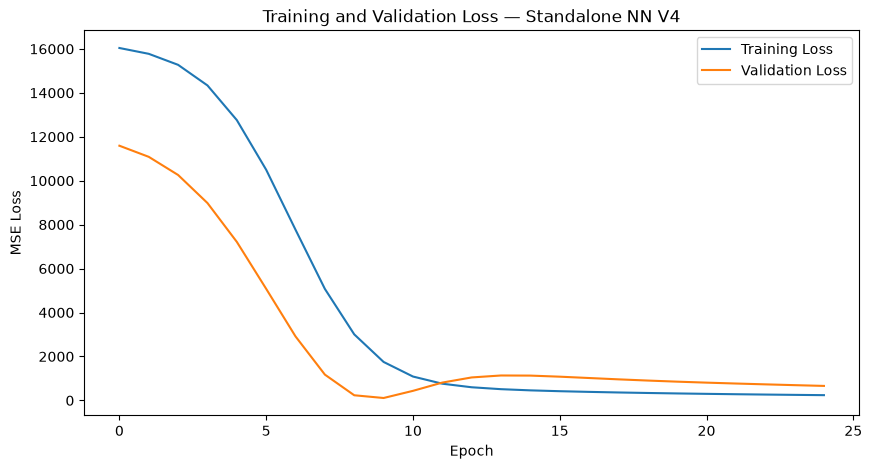

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss — Standalone NN V4')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.show()

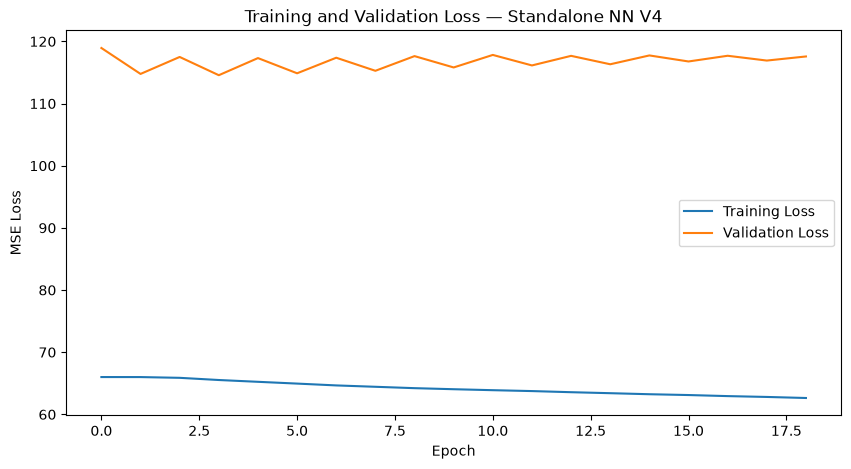

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss — Standalone NN V4')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

plt.show()

In [14]:
nn_predictions = nn_model.predict(X_test_scaled).flatten()
print("Prediction shape:", nn_predictions.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Prediction shape: (458,)


In [22]:
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_rmse = np.sqrt(
    mean_squared_error(y_test, nn_predictions)
)
nn_r2 = r2_score(
    y_test, nn_predictions
)
nn_mape = np.mean(
    np.abs(
        (y_test - nn_predictions) / y_test
    )
) * 100
nn_pearson, _ = pearsonr(
    y_test, nn_predictions
)
nn_spearman, _ = spearmanr(
    y_test, nn_predictions
)

print("Standalone Neural Network V4 Results")
print("--------------------------------------")
print(f"R² Score:          {nn_r2:.4f}")
print(f"MAE:               {nn_mae:.4f}")
print(f"RMSE:              {nn_rmse:.4f}")
print(f"MAPE:              {nn_mape:.2f}%")
print(f"Pearson:           {nn_pearson:.4f}")
print(f"Spearman:          {nn_spearman:.4f}")

Standalone Neural Network V4 Results
--------------------------------------
R² Score:          -8.4093
MAE:               13.0922
RMSE:              14.8490
MAPE:              10.84%
Pearson:           0.5126
Spearman:          0.5236


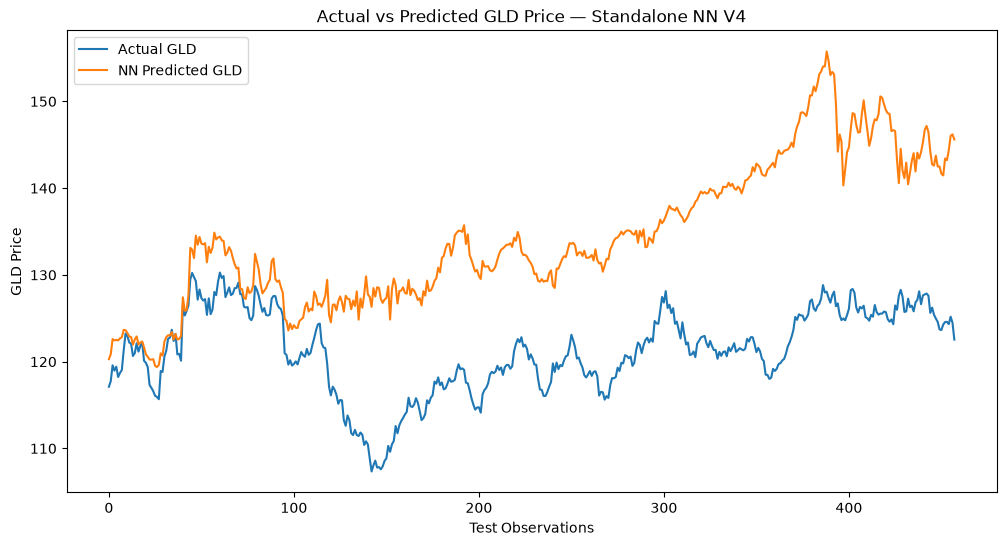

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label='Actual GLD'
)
plt.plot(
    nn_predictions,
    label='NN Predicted GLD'
)

plt.title('Actual vs Predicted GLD Price — Standalone NN V4')
plt.xlabel('Test Observations')
plt.ylabel('GLD Price')
plt.legend()

plt.show()

In [12]:
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 16210.8701 - val_loss: 11798.7246
Epoch 2/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16013.9287 - val_loss: 11529.4092
Epoch 3/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15711.1748 - val_loss: 11115.1104
Epoch 4/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15196.2900 - val_loss: 10460.7988
Epoch 5/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14294.5869 - val_loss: 9479.2314
Epoch 6/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12800.2383 - val_loss: 8045.6108
Epoch 7/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10656.8594 - val_loss: 6150.7603
Epoch 8/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8085.7183 - val_loss: 4073.2319
Epoch 9/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5497.6357 - val_loss: 2135.8474
Epoch 10/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3357.0574 - val_loss: 723.6398
Epoch 11/200
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1924.8208 - val_lo

In [15]:
nn_mae = mean_absolute_error(y_test, nn_predictions)
nn_rmse = np.sqrt(
    mean_squared_error(y_test, nn_predictions)
)
nn_r2 = r2_score(
    y_test, nn_predictions
)
nn_mape = np.mean(
    np.abs(
        (y_test - nn_predictions) / y_test
    )
) * 100
nn_pearson, _ = pearsonr(
    y_test, nn_predictions
)
nn_spearman, _ = spearmanr(
    y_test, nn_predictions
)

print("Standalone Neural Network V4 Results")
print("--------------------------------------")
print(f"R² Score:          {nn_r2:.4f}")
print(f"MAE:               {nn_mae:.4f}")
print(f"RMSE:              {nn_rmse:.4f}")
print(f"MAPE:              {nn_mape:.2f}%")
print(f"Pearson:           {nn_pearson:.4f}")
print(f"Spearman:          {nn_spearman:.4f}")

Standalone Neural Network V4 Results
--------------------------------------
R² Score:          -2.1802
MAE:               6.1384
RMSE:              8.6327
MAPE:              5.01%
Pearson:           0.1257
Spearman:          0.1837


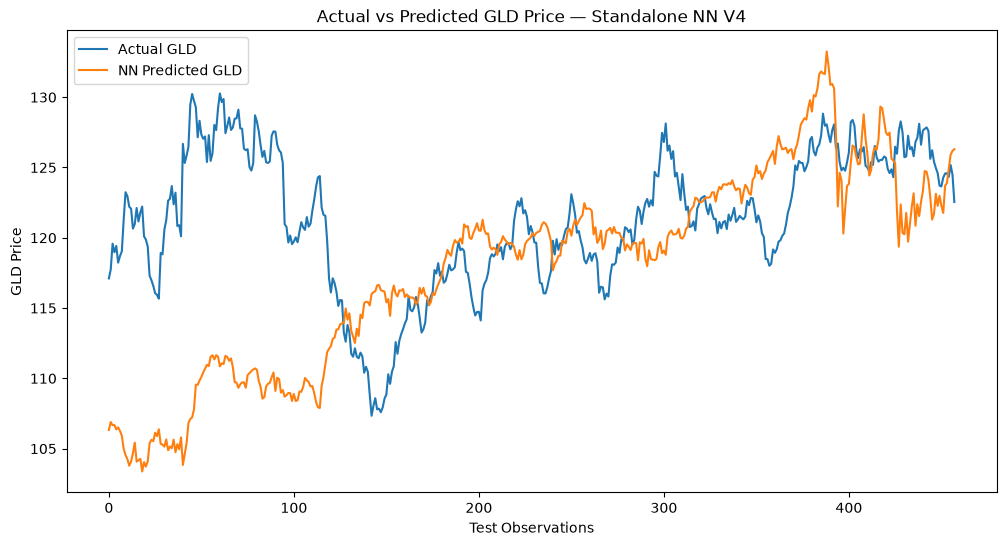

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(
    y_test.values,
    label='Actual GLD'
)
plt.plot(
    nn_predictions,
    label='NN Predicted GLD'
)

plt.title('Actual vs Predicted GLD Price — Standalone NN V4')
plt.xlabel('Test Observations')
plt.ylabel('GLD Price')
plt.legend()

plt.show()

In [17]:
print("Actual range:")
print(y_test.min(), y_test.max())

print("\nNN prediction range:")
print(nn_predictions.min(), nn_predictions.max())

print("\nFirst 10 actual:")
print(y_test.values[:10])

print("\nFirst 10 NN predictions:")
print(nn_predictions[:10])

Actual range:
107.339996 130.270004

NN prediction range:
103.37474 133.25053

First 10 actual:
[117.110001 117.739998 119.580002 118.970001 119.419998 118.230003
 118.699997 119.040001 121.290001 123.239998]

First 10 NN predictions:
[106.328064 106.892784 106.66703  106.67783  106.370445 106.51086
 106.25952  105.9189   104.995255 104.53734 ]
